### Detecção de Fraudes em Licitações Públicas com LSTM

Este notebook implementa um modelo LSTM para detecção de padrões suspeitos
em licitações públicas federais, utilizando dados reais coletados via API
do Portal da Transparência do Governo Federal.

**Estrutura:**
1. Instalação de dependências
2. Coleta de dados reais (API Portal da Transparência)
3. Pré-processamento
4. Preparação de séries temporais para LSTM
5. Construção da rede neural LSTM
6. Treinamento
7. Avaliação
8. Visualizações

In [1]:
# Executar apenas se necessário
#!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn requests python-dateutil
#!pip install python-dotenv

#### 1. Importações

In [2]:
import warnings
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("PORTAL_API_KEY")

headers = {
    "chave-api-dados": API_KEY
}

#### 2. Coleta de Dados Reais — API Portal da Transparência

Em vez de utilizar um dataset sintético, coletamos licitações reais de órgãos
federais via API oficial do Portal da Transparência.
A API exige uma chave de acesso gratuita, obtida em:
https://portaldatransparencia.gov.br/api-de-dados/cadastrar-email

Como a API limita a consulta a 1 mês por requisição, as funções abaixo
realizam a coleta mês a mês, paginando automaticamente, para os anos de 2022 e 2023.

In [4]:
headers = {'chave-api-dados': API_KEY}


def buscar_mes(codigo_orgao, data_inicial, data_final):
    """Coleta licitações de um único mês, página por página."""
    registros = []
    pagina = 1

    while True:
        r = requests.get(
            'https://api.portaldatransparencia.gov.br/api-de-dados/licitacoes',
            headers=headers,
            params={
                'codigoOrgao': codigo_orgao,
                'dataInicial': data_inicial,
                'dataFinal':   data_final,
                'pagina':      pagina
            },
            timeout=15
        )

        if r.status_code != 200:
            break

        dados = r.json()
        if not dados:
            break

        registros.extend(dados)

        if len(dados) < 500:  # menos de 500 indica última página
            break

        pagina += 1
        time.sleep(0.4)

    return registros


def buscar_periodo(codigos_orgao, ano_inicio, ano_fim):
    """Coleta dados de múltiplos órgãos, mês a mês, para o período informado."""
    if isinstance(codigos_orgao, str):
        codigos_orgao = {'Orgao': codigos_orgao}

    todos = []
    inicio = datetime(ano_inicio, 1, 1)
    fim    = datetime(ano_fim, 12, 31)

    for nome_orgao, codigo in codigos_orgao.items():
        atual = inicio
        while atual <= fim:
            fim_mes = atual + relativedelta(months=1) - relativedelta(days=1)
            if fim_mes > fim:
                fim_mes = fim

            registros = buscar_mes(
                codigo,
                atual.strftime('%d/%m/%Y'),
                fim_mes.strftime('%d/%m/%Y')
            )
            for reg in registros:
                reg['orgao_nome'] = nome_orgao

            todos.extend(registros)
            atual += relativedelta(months=1)
            time.sleep(0.5)

    return pd.DataFrame(todos)


# Órgãos federais consultados
orgaos = {
    'Ministerio da Saude':    '36000',
    'Ministerio da Educacao': '26000',
    'Ministerio da Defesa':   '52000',
}

df_real = buscar_periodo(orgaos, ano_inicio=2022, ano_fim=2023)

print(f'Total de registros coletados: {len(df_real)}')
print(f'Colunas disponíveis: {df_real.columns.tolist()}')
df_real.head()

Total de registros coletados: 903
Colunas disponíveis: ['id', 'licitacao', 'dataResultadoCompra', 'dataAbertura', 'dataReferencia', 'dataPublicacao', 'situacaoCompra', 'modalidadeLicitacao', 'instrumentoLegal', 'valor', 'municipio', 'unidadeGestora', 'orgao_nome']


,id,licitacao,dataResultadoCompra,dataAbertura,dataReferencia,dataPublicacao,situacaoCompra,modalidadeLicitacao,instrumentoLegal,valor,municipio,unidadeGestora,orgao_nome
0,1071538608,"{'numero': '000012022', 'objeto': 'Objeto: Tra...",2022-01-28,2022-01-14,2022-01-14,1900-01-01,Encerrado,Dispensa de Licitação,Sem informação,4658.00,"{'codigoIBGE': '5102702', 'nomeIBGE': 'CANARAN...","{'codigo': '257041', 'nome': 'DISTRITO SANIT.E...",Ministerio da Saude
1,1071770672,"{'numero': '000022022', 'objeto': 'Objeto: Aqu...",2022-02-11,2022-01-11,2022-01-11,1900-01-01,Encerrado,Dispensa de Licitação,Sem informação,3081.35,"{'codigoIBGE': '3304557', 'nomeIBGE': 'RIO DE ...","{'codigo': '250052', 'nome': 'INSTITUTO NACION...",Ministerio da Saude
2,1073046127,"{'numero': '000012022', 'objeto': 'Objeto: Aqu...",2022-02-03,2022-01-06,2022-01-06,1900-01-01,Encerrado,Dispensa de Licitação,Sem informação,12100.00,"{'codigoIBGE': '2507507', 'nomeIBGE': 'JOÃO PE...","{'codigo': '257046', 'nome': 'DISTRITO SANIT.E...",Ministerio da Saude
3,1075894967,"{'numero': '000022022', 'objeto': 'Objeto: Aqu...",2022-01-26,2022-01-06,2022-01-06,1900-01-01,Encerrado,Dispensa de Licitação,Sem informação,14499.99,"{'codigoIBGE': '3304557', 'nomeIBGE': 'RIO DE ...","{'codigo': '250104', 'nome': 'HOSPITAL FEDERAL...",Ministerio da Saude
4,1076990320,"{'numero': '000132021', 'objeto': 'Objeto: Pre...",2022-01-18,2022-01-04,2021-12-15,2021-12-15,Evento de Resultado de Julgamento Publicado,Pregão - Registro de Preço,Sem informação,103391.99,"{'codigoIBGE': '5101803', 'nomeIBGE': 'BARRA D...","{'codigo': '257040', 'nome': 'DISTRITO SANIT.E...",Ministerio da Saude


#### 3. Pré-processamento dos Dados

Seguindo a mesma lógica do código base, realizamos:
- Extração de campos aninhados (JSON dentro das colunas)
- Conversão de datas e valores
- Cálculo do tempo real entre abertura e resultado da licitação
- Criação da variável alvo `fraude` com base em critérios técnicos
- Codificação de variáveis categóricas com LabelEncoder
- Escalonamento com StandardScaler

In [5]:
df = df_real.copy()

df['orgao']     = df['unidadeGestora'].apply(lambda x: x.get('nome', 'Desconhecido') if isinstance(x, dict) else str(x))
df['municipio'] = df['municipio'].apply(lambda x: x.get('nomeIBGE', 'Desconhecido') if isinstance(x, dict) else str(x))
df['modalidade']= df['modalidadeLicitacao'].apply(lambda x: x if isinstance(x, str) else str(x))

df['data']             = pd.to_datetime(df['dataAbertura'], errors='coerce')
df['data_resultado']   = pd.to_datetime(df['dataResultadoCompra'], errors='coerce')
df['valor_estimado']   = pd.to_numeric(df['valor'], errors='coerce')
df['valor_homologado'] = df['valor_estimado']

df['tempo_licitacao_dias'] = (df['data_resultado'] - df['data']).dt.days.abs()

df = df.dropna(subset=['data', 'data_resultado', 'valor_estimado'])
df = df[df['valor_estimado'] > 0]
df = df.sort_values('data').reset_index(drop=True)

situacoes_risco = [
    'Evento de Suspensão Publicado',
    'Evento de Revogação Publicado',
    'Evento de Anulação Publicado',
    'Evento de Revogação Divulgado',
    'Evento de Adiamento Publicado',
]
df['situacao_risco']  = df['situacaoCompra'].isin(situacoes_risco).astype(int)
df['dispensa']        = (df['modalidade'] == 'Dispensa de Licitação').astype(int)
df['valor_alto']      = (df['valor_estimado'] > df['valor_estimado'].median() * 5).astype(int)
df['processo_rapido'] = (df['tempo_licitacao_dias'] < 5).astype(int)

score_fraud = (
    df['dispensa'] +
    df['valor_alto'] +
    df['situacao_risco'] +
    df['processo_rapido']
)
df['fraude'] = (score_fraud >= 2).astype(int)

print(f'Registros após limpeza: {len(df)}')
print(f'\nDistribuição de fraudes:')
print(df['fraude'].value_counts())
print(f'\nProporção de fraudes: {df["fraude"].mean()*100:.1f}%')
df[['data','orgao','modalidade','valor_estimado','tempo_licitacao_dias','fraude']].head(10)

Registros após limpeza: 723

Distribuição de fraudes:
fraude
0    667
1     56
Name: count, dtype: int64

Proporção de fraudes: 7.7%


,data,orgao,modalidade,valor_estimado,tempo_licitacao_dias,fraude
0,2022-01-04,DISTRITO SANIT.ESP.INDIGENA - XAVANTE,Pregão - Registro de Preço,103391.99,14.0,0
1,2022-01-04,INSTITUTO NACIONAL DE CARDIOLOGIA,Dispensa de Licitação,2432.70,37.0,0
2,2022-01-04,HOSPITAL DAS FORCAS ARMADAS,Pregão - Registro de Preço,69300.00,30.0,0
3,2022-01-05,CENTRO GESTOR OP. SISTEMA PROTECAO AMAZONIA,Pregão,22.00,7.0,0
4,2022-01-05,DEPARTAMENTO DE ADMINISTRACAO E DE PESSOAL,Pregão - Registro de Preço,78216.65,1.0,1
5,2022-01-06,DISTRITO SANIT.ESP.INDIGENA - POTIGUARA,Dispensa de Licitação,12100.00,28.0,0
6,2022-01-06,HOSPITAL FEDERAL CARDOSO FONTES,Dispensa de Licitação,14499.99,20.0,0
7,2022-01-06,INSTITUTO NACIONAL DO CANCER - RJ,Pregão - Registro de Preço,356850.00,6.0,0
8,2022-01-06,SUBSECRETARIA DE GESTAO ADMINISTRATIVA/MEC,Pregão - Registro de Preço,30979.95,13.0,0
9,2022-01-11,INSTITUTO NACIONAL DO CANCER - RJ,Dispensa de Licitação,3081.35,31.0,0


In [6]:
categorical_cols = ['orgao', 'modalidade']
numerical_cols   = ['valor_estimado', 'valor_homologado', 'tempo_licitacao_dias',
                    'situacao_risco', 'dispensa', 'valor_alto', 'processo_rapido']

df_model = df.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[categorical_cols + numerical_cols])
y = df_model['fraude'].values

print('Features após escalonamento (primeiras 5 linhas):')
print(X_scaled[:5])

Features após escalonamento (primeiras 5 linhas):
[[-0.45891119  1.15066749 -0.16871196 -0.16871196 -0.46056872 -0.18529642
  -0.6591842   1.49254098 -0.37467125]
 [ 0.68566621 -1.30341096 -0.19893825 -0.19893825  0.13581792 -0.18529642
   1.51702665 -0.66999835 -0.37467125]
 [ 0.01238539  1.15066749 -0.17891879 -0.17891879 -0.04569106 -0.18529642
  -0.6591842  -0.66999835 -0.37467125]
 [-2.27676942 -0.07637174 -0.19965999 -0.19965999 -0.64207769 -0.18529642
  -0.6591842  -0.66999835 -0.37467125]
 [-2.14211326  1.15066749 -0.17624923 -0.17624923 -0.79765682 -0.18529642
  -0.6591842   1.49254098  2.66900646]]


#### 4. Preparação de Séries Temporais para LSTM

A LSTM espera entrada 3D: (amostras, passos_temporais, features).

Os dados são organizados em janelas temporais de tamanho 10, onde cada janela representa uma sequência de 10 licitações consecutivas no tempo.

In [7]:
def create_sequences(data, labels, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i + window_size])
        y_seq.append(labels[i + window_size - 1])
    return np.array(X_seq), np.array(y_seq)


WINDOW_SIZE = 10
X_seq, y_seq = create_sequences(X_scaled, y, window_size=WINDOW_SIZE)

print('Shape das sequências de entrada:', X_seq.shape)
print('Shape dos rótulos:', y_seq.shape)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print(f'\nTreino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Fraudes no treino: {y_train.sum()} | Fraudes no teste: {y_test.sum()}')

Shape das sequências de entrada: (713, 10, 9)
Shape dos rótulos: (713,)

Treino: (570, 10, 9) | Teste: (143, 10, 9)
Fraudes no treino: 35 | Fraudes no teste: 20


#### 5. Construção da Rede Neural LSTM

Arquitetura idêntica ao código base: duas camadas LSTM com Dropout, camada densa intermediária e saída sigmoide.

Como os dados reais são desbalanceados (~7,7% de fraudes), adicionamos class_weight para que o modelo penalize mais os erros em casos de fraude.

In [8]:
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, n_features)),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Resumo da arquitetura da rede LSTM:')
model.summary()

Resumo da arquitetura da rede LSTM:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

#### 6. Treinamento da LSTM

Utilizamos EarlyStopping para interromper o treinamento caso a perda de validação
pare de melhorar, evitando overfitting e economizando tempo computacional.

In [9]:
peso_fraude = len(y_train) / (2 * y_train.sum())
peso_normal = len(y_train) / (2 * (len(y_train) - y_train.sum()))
class_weight = {0: peso_normal, 1: peso_fraude}
print(f'Pesos — Normal: {peso_normal:.2f} | Fraude: {peso_fraude:.2f}')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Pesos — Normal: 0.53 | Fraude: 8.14
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8991 - loss: 0.6910 - val_accuracy: 0.9035 - val_loss: 0.6398
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7895 - loss: 0.6750 - val_accuracy: 0.8158 - val_loss: 0.6014
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7478 - loss: 0.6487 - val_accuracy: 0.7105 - val_loss: 0.5835
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7368 - loss: 0.6239 - val_accuracy: 0.7193 - val_loss: 0.5663
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6294 - loss: 0.5970 - val_accuracy: 0.7281 - val_loss: 0.5423
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7456 - loss: 0.5422 - val_accuracy: 0.7807 - val_loss: 0.4517
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7939 - loss: 0.4435 - val_accuracy: 0.7719 - val_loss: 0.4463
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8399 - los

#### 7. Avaliação do Modelo

Avaliamos com as métricas clássicas de classificação binária:
matriz de confusão, acurácia, precisão, recall e F1-score.

In [10]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print('Matriz de Confusão:')
print(cm)
print()
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=['Nao Fraude', 'Fraude']))
print('Acurácia no teste:', accuracy_score(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Matriz de Confusão:
[[118   5]
 [  0  20]]

Relatório de Classificação:
              precision    recall  f1-score   support

  Nao Fraude       1.00      0.96      0.98       123
      Fraude       0.80      1.00      0.89        20

    accuracy                           0.97       143
   macro avg       0.90      0.98      0.93       143
weighted avg       0.97      0.97      0.97       143

Acurácia no teste: 0.965034965034965


#### 8. Visualizações

##### 8.1 Curvas de Aprendizado

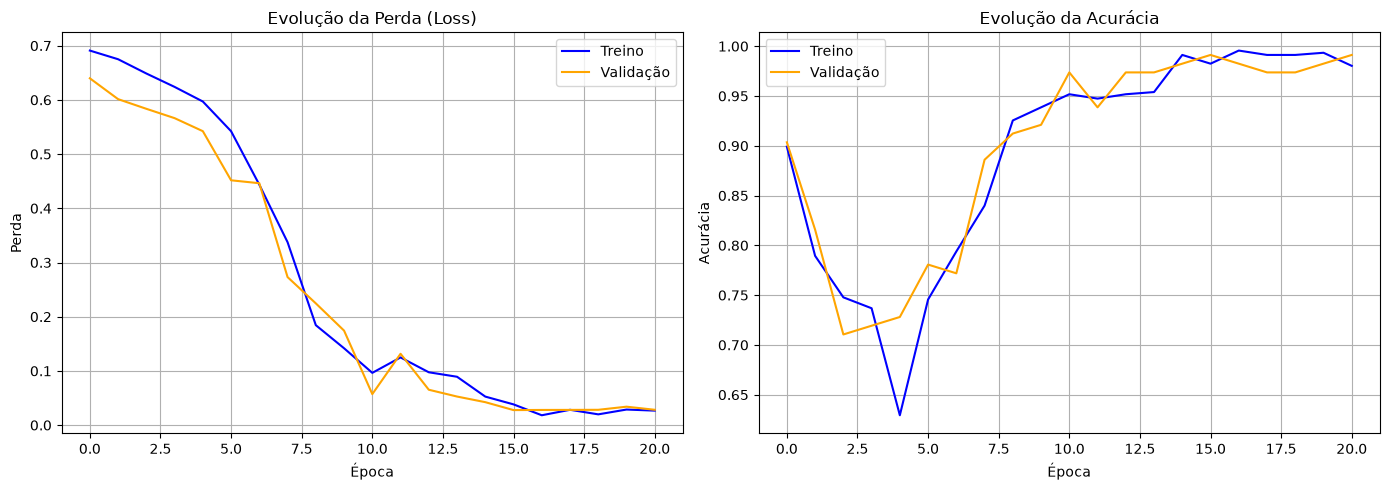

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Treino',    color='blue')
axes[0].plot(history.history['val_loss'], label='Validação', color='orange')
axes[0].set_title('Evolução da Perda (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Perda')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Treino',    color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validação', color='orange')
axes[1].set_title('Evolução da Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lstm_fraud_detection_metrics.png', dpi=300)
plt.show()

##### 8.2 Matriz de Confusão

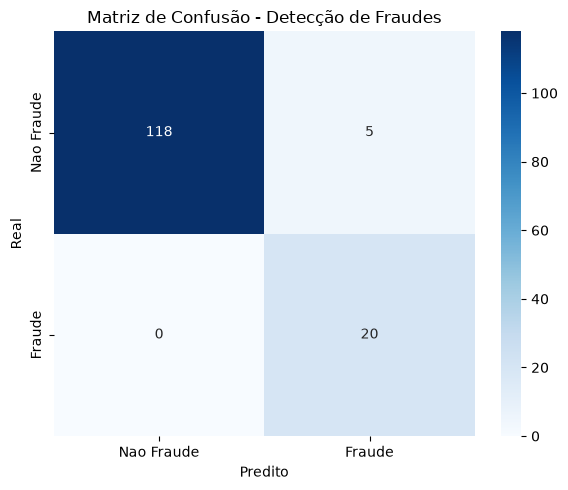

Treinamento e avaliação concluídos com sucesso.
Gráficos salvos: lstm_fraud_detection_metrics.png e confusion_matrix_fraud.png


In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nao Fraude', 'Fraude'],
            yticklabels=['Nao Fraude', 'Fraude'])
plt.title('Matriz de Confusão - Detecção de Fraudes')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_fraud.png', dpi=300)
plt.show()

print('Treinamento e avaliação concluídos com sucesso.')
print('Gráficos salvos: lstm_fraud_detection_metrics.png e confusion_matrix_fraud.png')

#### Conclusão

Os dados foram coletados da API do Portal da Transparência, resultando em **723 registros válidos**, dos quais **7,7%** foram classificados como potenciais fraudes. Após o pré-processamento e a criação de sequências temporais, uma rede **LSTM** foi treinada para identificar padrões de comportamento nas licitações.

O modelo apresentou **96,5% de acurácia**, com **100% de recall** para a classe fraude, identificando todas as fraudes presentes no conjunto de teste. Houve apenas **5 falsos positivos** e nenhum falso negativo, demonstrando um bom equilíbrio entre precisão e capacidade de detecção.

Esses resultados indicam que a arquitetura LSTM é adequada para apoiar a detecção de possíveis irregularidades em licitações públicas, podendo servir como uma ferramenta de apoio à auditoria e ao controle preventivo, embora estudos futuros com bases maiores e fraudes confirmadas possam tornar o modelo ainda mais robusto.
